In [56]:
import os
import re

import numpy as np
from numpy.random import randint, normal, uniform
import pylab as pl
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from joblib import Parallel, delayed

from astropy import units as u

import healpy as hp
import camb

from ksw import Cosmology, Data, ReducedBispectrum, KSW
from ksw.radial_functional import radial_func

import h5py

%matplotlib inline

# Data Generator

This code primamrly uses [KSW](https://github.com/AdriJD/ksw/tree/master/src), as a means to generate non-gaussian cmb maps. These get stored in a data file with the fnls, fullsky maps, and patches.

The fullsky maps are generated using the method discussed in [CMB lensing and primordial non-Gaussianity](https://arxiv.org/abs/0905.4732), where we find (eq. 6) 
$$
a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}{^{NG}}
$$
and generated the full sky map by passing these $a_{\ell m}$ into healpy.

Most of this code is to calculate the term (eq. 27)

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

and

$$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$$

$$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$$

$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

where $\Delta_\phi$ is pridormial normalizatiopn, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions

---

## Settings

See: https://camb.readthedocs.io/en/latest/model.html

Some values are forced during init of ksw.Cosmology. 
For an example on how to modify these values after init: https://github.com/AdriJD/ksw/blob/fba3250cfe4c5145b5db12fa54bbc54bbcf5a56c/tests/python/test_cosmology.py#L65

In [57]:
cosmo_params = {
    'H0': 67.5,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'pivot_scalar': 0.05,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'mnu': 0.06,
    'tau': 0.0561,
    'TCMB': 2.7255,
    'max_l': 3000,


    ## These are forced by ksw
    # "DoLateRadTruncation": False,
    # "AccuracyBoost":2.,
    # "BessIntBoost": 30.,
    # "KmaxBoost": 3.,
    # "IntTolBoost": 4.,
    # "TimeStepBoost": 4.,
    # "SourcekAccuracyBoost": 5.,
    # "BesselBoost": 5.,
    # "IntkAccuracyBoost": 5.,
    # "lSampleBoost": 2.,
    # "lAccuracyBoost": 2.,
    # "AccurateBB": True,
}

lmax >= 300 is enforced by the ksw code due to errors with CAMB. 
lmax needs to be somewhat smaller then max_l, if you get errors about c_ell change these.
You will get warning messages if lmax > 4\* nside.  

nside should be of type 2\*\*n

num_patches should be even.

patch_side_deg \* num_patches \<\= 180, patch_side_deg \<\= 45; or you will overlap patches 

r_max is given in Mpc, we preform r_res slices over this volume to do the integral. Values have been picked by guestimation, with r_res being set low to help test. Will want to raise this for better calculations.

KSW only supports polarization values of 'T', 'E', ['T', 'E'].

In [58]:
fnl_range=(-1000, 1000)

nsims = 10
npatches = 10                # number of patches to generate per sim
save_size = 10               # save every n sims, helps control memory usage

lmax=2000
nside=512

patch_side_deg = 10

r_res = 1000                  # number of slices in the radius, memory and time are greatly impacted by this
r_batch = 10                 # number of slices to compute per thread, memory usage is greatly impacted by this

r_min = 1                    # Mpc, min radius for the patch, >1e-6, but I've had issues below 1 with kernel crashes, check if this should be higher       
r_max = 14000                # Mpc, max radius for the patch, should be > SLS distance, check this value

# KSW only supports 'T' and 'E', need to check 'E' Support
# more testing needs to be done with TE
polarizations = 'T'
# polarizations = ['T', 'E']

# FWHM of gaussian beam, use astropy units to make thing easy here
beam_width = 7 * u.arcmin # type: ignore

# noise settings, for the noise covariance matrix (without beam) in uK^2.
noise_loc = 0.
noise_scale = 43 * (cosmo_params['TCMB']* 1e-6)**2

# not fully tested
lensing = False

# should we save the full sky maps, or just the patches
save_fullsky = True


We set the file name best on settings, this will let us load in the data better and ensure we know what settings we are dealing with

In [59]:
if isinstance(polarizations, str):
    chars_of_polarizations = polarizations
elif isinstance(polarizations, list):
    chars_of_polarizations = ''.join(polarizations)
else:
    raise TypeError("polarizations must be either a string or a list of strings")

base_name = f'{nside}_{nsims}x{npatches}_fnl{fnl_range[0]}-{fnl_range[1]}_r{r_res}_p{chars_of_polarizations}'
data_dir = f'data/ksw'
filename = f'{base_name}.hdf5.nc'
data_file = os.path.join(data_dir, filename)

print(f'running sims for {base_name}')

running sims for 512_10x10_fnl-1000-1000_r1000_pT


In [60]:
if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
else:
    print(f'Reusing directory {data_dir}')
    # pattern = re.compile(f"{base_name}_\d+-\d+\.npy")
    pattern = re.compile(f"{base_name}\.hdf5(\.nc)?")
    for file in os.listdir(data_dir):
        if pattern.match(file):
            file_path = os.path.join(data_dir, file)
            os.remove(file_path)
            print(f"Deleted existing data file: {file_path}")

Reusing directory data/ksw


In [61]:
npol = 1 if isinstance(polarizations, str) else len(polarizations)
pol_b = npol > 1

nell = lmax + 1
nelem = hp.Alm.getsize(lmax)
npix = hp.nside2npix(nside)
ells = np.arange(nell)

ls, ms = hp.Alm.getlm(lmax)

print(npol, pol_b, nell, ls.shape, ms.shape, npix)

1 False 2001 (2003001,) (2003001,) 3145728


In [62]:
# np.split didnt do what I wanted
def split_into_batches(data, batch_size):
    batches = []
    indices = []
    
    # number of complete batches
    num_batches = len(data) // batch_size
    
    for i in range(num_batches):
        batches.append(data[i*batch_size:(i+1)*batch_size])
        indices.append(np.arange(i*batch_size, (i+1)*batch_size))
    
    # if there are leftover elements
    if len(data) % batch_size != 0:
        batches.append(data[num_batches*batch_size:])
        indices.append(np.arange(num_batches*batch_size, len(data)))
        
    return indices, batches

radii = np.linspace(r_min, r_max, r_res)
dr = radii[1] - radii[0]

sim_idxs, sim_slices = split_into_batches(np.arange(nsims), save_size)
radii_idxs, radii_slices = split_into_batches(radii, r_batch)

print(len(sim_slices), len(radii_idxs), len(radii_slices))

1 100 100


In [63]:
# Order for pol_b is TT,EE,TE
noise_ell = normal(noise_loc, noise_scale, (3, nell) if pol_b else (nell))

beam_ell = hp.gauss_beam(beam_width.to_value(u.radian), lmax, pol_b)

if pol_b:
    beam_ell = beam_ell.swapaxes(0,1)

# noise_ell = np.arange(nell, dtype=float)
# beam_ell = np.linspace(1, 0.8, nell)

print(noise_ell.shape, beam_ell.shape)

(2001,) (2001,)


## Simulate the patches

In [64]:
camb_params_obj = camb.set_params(**cosmo_params)
cosmo = Cosmology(camb_params_obj, verbose=True)

# Additional settings here
# cosmo._setattr_camb('ns', 0.9624, subclass='InitPower')

# notice 3000 > lmax, will get warnings otherwise
cosmo.compute_transfer(cosmo_params['max_l'])

cosmo.compute_c_ell()

Updated CAMB param: DoLateRadTruncation from True to False.
Updated CAMB param: AccuracyBoost from 1.0 to 2.
Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: lSampleBoost from 1.0 to 2.
Updated CAMB param: lAccuracyBoost from 1.0 to 2.
Updated CAMB param: AccurateBB from False to True.


In [65]:
data = Data(lmax, noise_ell, beam_ell, polarizations, cosmo, n_is_totcov=False)

alm = data.compute_alm_sim(lensing)

# 0 gets only T
pre = '' if lensing else 'un'
c_ells = data.cosmology.c_ell[pre+'lensed_scalar']['c_ell'][:,:npol] # type: ignore

tr_ell_k = data.cosmology.transfer['tr_ell_k']
tr_ells = data.cosmology.transfer['ells']
tr_k = data.cosmology.transfer['k']

print(alm.shape, tr_ell_k.shape, tr_ells.shape, tr_k.shape, c_ells.shape)

(1, 2003001) (147, 27558, 2) (147,) (27558,) (2501, 1)


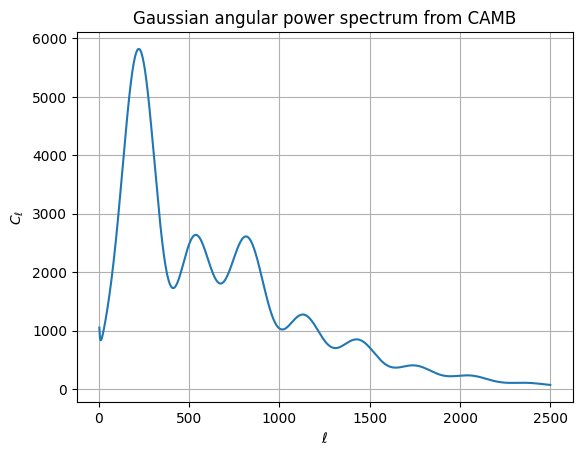

In [66]:
plt.figure()
ls = np.arange(len(c_ells[:,0]))[2:]
plt.plot(ls, ls * (ls + 1) / 2 / np.pi * c_ells[2:,0])
plt.xlabel("$\ell$")
plt.ylabel("$C_{\ell}$")
plt.title("Gaussian angular power spectrum from CAMB")
plt.grid()
plt.show()

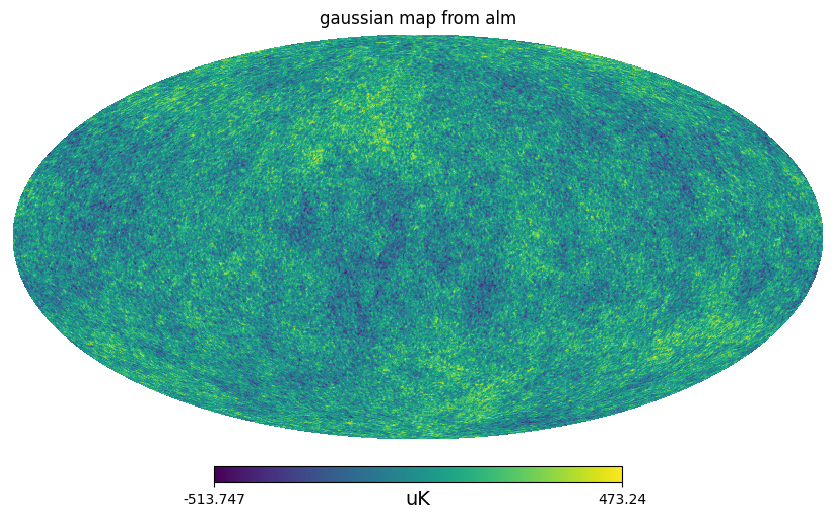

In [67]:
gaussian_map = hp.alm2map(alm, nside=nside, lmax=lmax, pol=pol_b)
hp.mollview(gaussian_map[0], title='gaussian map from alm', unit='uK')

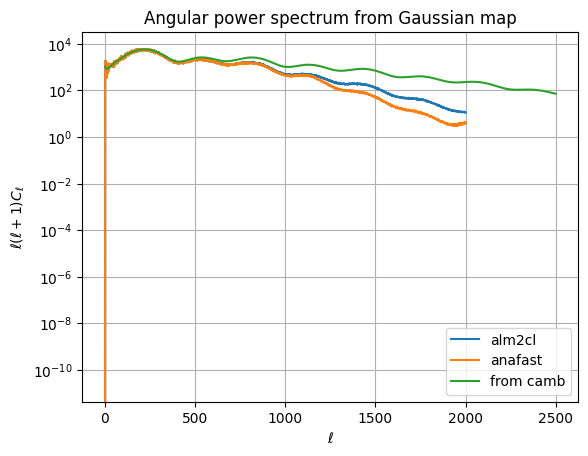

In [68]:
cl1 = hp.anafast(gaussian_map[0], lmax=lmax, pol=pol_b)
cl2 = hp.alm2cl(alm[0], lmax=lmax)
ell = np.arange(len(cl1))

scale = ell * (ell + 1) / 2 / np.pi

plt.semilogy(ell, scale * cl2, label='alm2cl')
plt.semilogy(ell, scale * cl1, label='anafast')
plt.semilogy(ls, ls * (ls + 1) / 2 / np.pi * c_ells[2:,0], label='from camb')
plt.xlabel("$\ell$")
plt.ylabel("$\ell(\ell+1)C_{\ell}$")
plt.title('Angular power spectrum from Gaussian map')
plt.legend()
plt.grid()

Radial func computes $f_\ell^X(r) = \frac{2}{\pi} \int k^2 dk f(k) \Delta^{TX}_\ell(k) j_\ell(k r)$, we will use this to find 
$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$
and
$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$. 
$\Delta_\ell^T(k)$, the transfer functions, are calculated sparsely by CAMB; We thus need to interpolate over the missing values to get `alpha_l`, `beta_l` which are suitable for the calculations. We do this with CubicSpline, but this could be changed if needed. We also go ahead and calculate `bl_div_cl`=$\beta_\ell / C_\ell$, which is used to calculate $B(r,\hat{n})$.

In [69]:
def interpolate_ells(func, ells_sparse, ls):
    return CubicSpline(ells_sparse, func, axis=1)(ls)

delta_phi = 2 * np.pi ** 2 * cosmo_params['As'] * (3 / 5)**2

f_k_alpha = np.ones((len(tr_k)))
f_k_beta = (tr_k**-3 * delta_phi)
f_k = np.reshape([f_k_alpha, f_k_beta], (-1, 2))

rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

alpha_ell = rad[:,:,:,0]
alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, ells)]))
alpha_l = np.ascontiguousarray(alpha_l)

beta_ell = rad[:,:,:,1]
c_ells_new = c_ells[tr_ells]
div = beta_ell / c_ells_new[np.newaxis, :, :]

bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, ells)]))
bl_div_cl = np.ascontiguousarray(bl_div_cl)

print(alpha_l.shape, bl_div_cl.shape)

(1000, 2001, 2) (1000, 2001, 2)


$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

In [70]:
def get_alm_ng_slice():
    for p in range(npol):
        for r_idxs, rs in zip(radii_idxs, radii_slices):
                yield bl_div_cl[r_idxs,:,p], alpha_l[r_idxs,:,p], rs, p

def alm_ng_slice(dr, nside, lmax, pol_b, alm, bl_div_cl, alpha_l, radii):
    Balm = np.array([ hp.almxfl(alm, bl_div_cl[i]) for i in range(len(radii)) ])

    B = hp.alm2map(Balm, nside=nside, lmax=lmax, mmax=None, pol=pol_b, pixwin=False, fwhm=0, sigma=None)

    inner = hp.map2alm(B**2, lmax=lmax, mmax=None, pol=pol_b)

    alm_ng = np.array([dr * radii[i]**2 * hp.almxfl(inner[i], alpha_l[i]) for i in range(len(radii))])   
    return np.sum(alm_ng, axis=0) # type: ignore
        
alm_ng = Parallel(n_jobs=-1, verbose=11)(delayed(alm_ng_slice)(dr, nside, lmax, pol_b, alm[p], bldivcls, alphals, rs) # type: ignore
                for bldivcls, alphals, rs, p in get_alm_ng_slice())
alm_ng = np.sum(alm_ng, axis=0)
alm_ng = np.reshape(alm_ng, (npol, alm.shape[1]))
alm_ng = np.ascontiguousarray(alm_ng)

print(alm_ng.shape)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [ ]:
def cutSqPatches(fullsky_map, img_size, side_deg, num_patches):
    Tmap_datat = np.zeros((num_patches//2, int(img_size), int(img_size)))
    Tmap_datab = np.zeros((num_patches//2, int(img_size), int(img_size)))

    for counter in range(num_patches//2):
        Tmap_datat[counter] = np.ma.getdata(hp.cartview(fullsky_map, 
                                                            fig=0, 
                                                            xsize=img_size, 
                                                            ysize=img_size, 
                                                            rot=[0, 0], 
                                                            lonra=[side_deg*counter, side_deg*(counter+1)], 
                                                            latra=[0, side_deg],
                                                            title="CartView", 
                                                            unit="mK", 
                                                            format="%.2g", 
                                                            return_projected_map=True))
        
        Tmap_datab[counter] = np.ma.getdata(hp.cartview(fullsky_map, 
                                                            fig=1, 
                                                            xsize=img_size, 
                                                            ysize=img_size, rot=[0, 0], 
                                                            lonra=[side_deg*counter, side_deg*(counter+1)], 
                                                            latra=[-side_deg, 0],
                                                            title="CartView", 
                                                            unit="mK", 
                                                            format="%.2g", 
                                                            return_projected_map=True))
        
    return np.concatenate((Tmap_datat, Tmap_datab))

def append_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'a') as f:
        for key, value in data_dict.items():
            # If dataset exists in file, append to it
            if key in f:
                f[key].resize((f[key].shape[0] + value.shape[0]), axis = 0)
                f[key][-value.shape[0]:] = value
            else:
                maxshape = (None,) + value.shape[1:]
                dataset = f.create_dataset(key, shape=value.shape, maxshape=maxshape, chunks=True)
                dataset[:] = value 

fnls are generated per sim, so each patch for each sim has the same fnl

In [ ]:
fnls = uniform(fnl_range[0], fnl_range[1], nsims).astype(np.float32)
append_to_hdf5(data_file, {'fnls': fnls})

In [ ]:
def get_sim_run(sims):
    for p in range(npol):
        for sim in sims:
                    yield sim, p

def run_sim(nside, npatches, patch_side_deg, lmax, pol_b, alm, alm_ng, fnl):
    alm_prime = alm + fnl * alm_ng

    # do we have sufficent randomization here?
    # we might need to add a randomized noise alm
    maps = hp.alm2map(alm_prime, nside, lmax=lmax, mmax=None, pol=pol_b, pixwin=False, fwhm=0, sigma=None)

    patches = cutSqPatches(maps, nside, patch_side_deg, npatches)   
    return (maps, patches)

pl.ioff()
with Parallel(n_jobs=-1, verbose=11) as parallel:
    for sims in sim_slices:
        sim_data = parallel(delayed(run_sim)(nside, npatches, patch_side_deg, lmax, pol_b, alm[p], alm_ng[p], fnls[sim]) 
            for sim, p in get_sim_run(sims))

        # there has to be a better way to do this
        maps = np.array([data[0] for data in sim_data]).reshape(npol, len(sims), npix)
        patches = np.array([data[1] for data in sim_data]).reshape(npol, len(sims), npatches, nside, nside)
        
        print('saving', save_fullsky, maps.shape, patches.shape)
        data_dict = {'patches': patches}
        if save_fullsky:
             data_dict['maps'] = maps

        append_to_hdf5(data_file, data_dict)
    
pl.close('all')
pl.ion()

print('done with sims') 

In [ ]:
os.rename(data_file, data_file.replace('.hdf5.nc', '.hdf5'))

Done with generation

---

# Tests

In [ ]:
random_indices = [(randint(npol), randint(maps.shape[0]), randint(npatches)) for _ in range(4)]

print(random_indices)

In [ ]:
for pol, sim, patch in random_indices:
    hp.mollview(maps[pol, sim], title=f'Sim {sim}, pol {pol}, fnl {fnls[sim]}', unit='mK')

In [ ]:
print(patches.shape)
for pol, sim, patch in random_indices:
    plt.figure()
    plt.imshow(patches[pol, sim, patch])
    plt.title(f"sim {sim} patch {patch}, pol {pol} [fnl={fnls[sim]}]")
    plt.show()

In [ ]:
for pol, sim, patch in random_indices:
    cl = hp.anafast(maps[pol, sim], lmax=lmax)
    ell = np.arange(len(cl))
    
    plt.figure()
    plt.semilogx(ell, ell * (ell + 1) * cl)
    plt.title(f"sim {sim} pol {pol} [fnl={fnls[sim]}]")
    plt.show()

In [ ]:
n_unique = 2
nfact = 3

factors = np.ones((n_unique, npol, nell))
weights = np.ones((nfact, 3))
rule = np.zeros((nfact, 3), dtype=int)
rule[0] = [0, 0, 0]
rule[1] = [0, 0, 1]
rule[2] = [0, 1, 1]
beam = lambda alm : alm
red_bi = [ReducedBispectrum(factors, rule, weights, ells, 'tester')]

icov_nl = data.icov_diag_nonlensed
est_nl = KSW(red_bi, icov_nl, beam, lmax, polarizations)

alm = np.array([hp.map2alm(maps[0,0], lmax=lmax)])
est_nl.step(np.array([hp.map2alm(maps[0,0], lmax=lmax)]))
est_nl.step(np.array([hp.map2alm(maps[0,1], lmax=lmax)]))
est_nl.step(np.array([hp.map2alm(maps[0,2], lmax=lmax)]))
est_nl.step(np.array([hp.map2alm(maps[0,3], lmax=lmax)]))
est_nl.step(np.array([hp.map2alm(maps[0,4], lmax=lmax)]))

print(est_nl.compute_linear_term(alm.copy()))
print('fnl estimate', est_nl.compute_estimate(alm.copy()))

# Goodbye